# WP diagram: Robertson DAE

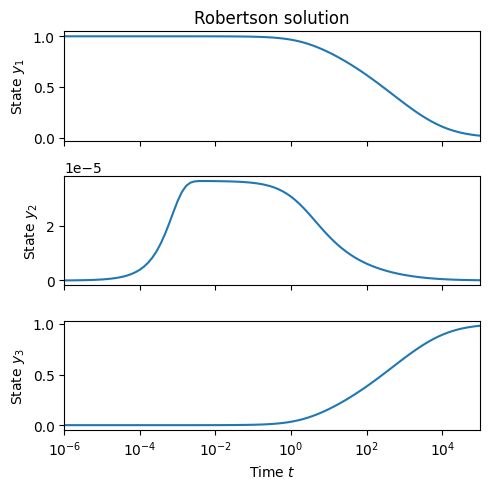

  0%|                                                     | 0/6 [00:00<?, ?it/s]

DAE | Jet(3):   0%|                                       | 0/6 [00:00<?, ?it/s]

DAE | Jet(3):  17%|█████▏                         | 1/6 [00:02<00:12,  2.50s/it]

DAE | Jet(4):  17%|█████▏                         | 1/6 [00:02<00:12,  2.50s/it]

DAE | Jet(4):  33%|██████████▎                    | 2/6 [00:05<00:10,  2.72s/it]

...

ODE | TS1(7):  67%|████████████████████▋          | 4/6 [00:10<00:04,  2.47s/it]

ODE | TS1(7):  83%|█████████████████████████▊     | 5/6 [00:11<00:01,  1.94s/it]

ODE | LSODA (Scipy):  83%|████████████████████    | 5/6 [00:11<00:01,  1.94s/it]

ODE | LSODA (Scipy): 100%|████████████████████████| 6/6 [00:11<00:00,  1.39s/it]

ODE | LSODA (Scipy): 100%|████████████████████████| 6/6 [00:11<00:00,  1.96s/it]

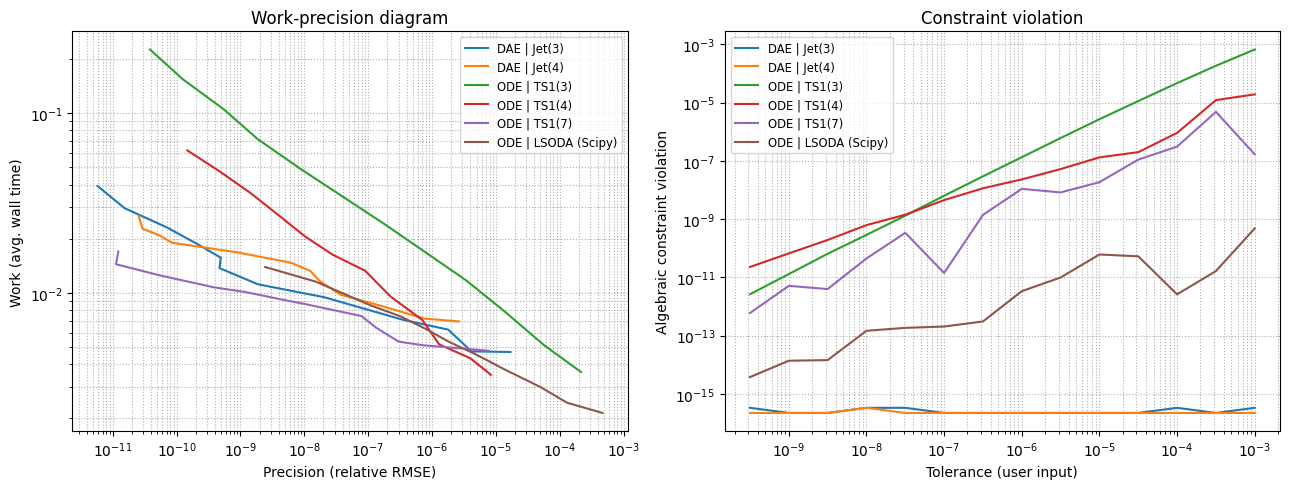

In [1]:
"""Work-precision diagram on the Robertson problem.

The Robertson problem is interesting for many reasons:
- It has an exponential timescale so (good) adaptive
  steps are needed; fixed steps are hopeless.
- Its y-states have wildly different scales,
  so a good prior model is important.

"""

import functools
import statistics
import timeit
from collections.abc import Callable

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import scipy.integrate
import tqdm

from probdiffeq import ivpsolve, probdiffeq, taylor
from probdiffeq.util import nlstsq_util

# Fail this notebook on NaN detection (to catch those in the CI)
jax.config.update("jax_debug_nans", True)


def main(start=3.0, stop=10.0, step=0.5, repeats=2, time_span=(1e-6, 1e5)) -> None:
    """Run the script."""
    # Set up all the configs
    jax.config.update("jax_enable_x64", True)

    # Simulate once to plot the state
    t0, t1 = time_span
    save_at = jnp.exp(jnp.linspace(jnp.log(t0), jnp.log(t1), num=100))
    ts, ys = solve_ivp_once(save_at=save_at, tol=1e-10, method="LSODA")

    _fig, ax = plt.subplots(nrows=3, figsize=(5, 5), sharex=True)
    ax[0].set_title("Robertson solution")
    ax[0].semilogx(ts, 1e-10 + ys[:, 0])
    ax[1].semilogx(ts, 1e-10 + ys[:, 1])
    ax[2].semilogx(ts, 1e-10 + ys[:, 2])

    ax[0].set_ylabel("State $y_1$")
    ax[1].set_ylabel("State $y_2$")
    ax[2].set_ylabel("State $y_3$")
    ax[2].set_xlabel("Time $t$")
    ax[0].set_xlim((t0, t1))
    plt.tight_layout()
    plt.show()

    # Read configuration from command line
    tolerances = setup_tolerances(start=start, stop=stop, step=step)
    timeit_fun = setup_timeit(repeats=repeats)

    # Assemble algorithms
    algorithms = {
        "DAE | Jet(3)": solver_dae_iwp(num_derivatives=3, time_span=time_span),
        "DAE | Jet(4)": solver_dae_iwp(num_derivatives=4, time_span=time_span),
        "ODE | TS1(3)": solver_ode(num_derivatives=3, time_span=time_span),
        "ODE | TS1(4)": solver_ode(num_derivatives=4, time_span=time_span),
        "ODE | TS1(7)": solver_ode(num_derivatives=7, time_span=time_span),
        "ODE | LSODA (Scipy)": solver_scipy(method="LSODA", time_span=time_span),
    }

    # Compute a reference solution
    reference = solver_scipy(method="Radau", time_span=time_span)(0.1 * tolerances[-1])
    rmse_fun = rmse_relative(reference)

    # Compute all work-precision diagrams
    results = {}
    pbar = tqdm.tqdm(algorithms.items())
    for label, algo in pbar:
        pbar.set_description(label)
        param_to_wp = workprec(algo, precision_fun=rmse_fun, work_fun=timeit_fun)
        results[label] = param_to_wp(tolerances)
    _fig, ax = plt.subplots(ncols=2, figsize=(13, 5))

    for label, wp in results.items():
        wdw = 3  # window

        precision, y = wp["precision"], wp["work_mean"]
        x, _ = precision.T
        x = jnp.exp(jnp.convolve(jnp.log(x), jnp.ones((wdw,)) / wdw, mode="valid"))
        y = jnp.exp(jnp.convolve(jnp.log(y), jnp.ones((wdw,)) / wdw, mode="valid"))
        ax[0].loglog(x, y, label=label)

        x, size = precision.T
        eps = jnp.finfo(x.dtype).eps
        ax[1].loglog(tolerances, eps + jnp.abs(size - 1.0), "-", label=label)

    ax[0].set_title("Work-precision diagram")
    ax[0].set_xlabel("Precision (relative RMSE)")
    ax[0].set_ylabel("Work (avg. wall time)")
    ax[0].grid(linestyle="dotted", which="both")
    ax[0].legend(fontsize="small")

    ax[1].set_title("Constraint violation")
    ax[1].set_xlabel("Tolerance (user input)")
    ax[1].set_ylabel("Algebraic constraint violation")
    ax[1].grid(linestyle="dotted", which="both")
    ax[1].legend(fontsize="small")

    plt.tight_layout()
    plt.show()


def solve_ivp_once(*, save_at, method, tol):
    """Compute plotting-values for the IVP."""

    def vf(t, y):
        del t
        k1, k2, k3 = 0.04, 3e7, 1e4
        f0 = -k1 * y[0] + k3 * y[1] * y[2]
        f1 = k1 * y[0] - k2 * y[1] ** 2 - k3 * y[1] * y[2]
        f2 = k2 * y[1] ** 2
        return np.stack([f0, f1, f2])

    y0 = jnp.array([1.0, 0.0, 0.0])

    t0, t1 = save_at[0], save_at[-1]
    solution = scipy.integrate.solve_ivp(
        vf,
        y0=y0,
        t_span=(t0, t1),
        t_eval=save_at,
        atol=1e-3 * tol,
        rtol=tol,
        method=method,
    )
    return solution.t, solution.y.T


def setup_tolerances(*, start: float, stop: float, step: float) -> jax.Array:
    """Choose vector of tolerances from the command-line arguments."""
    return 0.1 ** jnp.arange(start, stop, step=step)


def setup_timeit(*, repeats: int) -> Callable:
    """Construct a timeit-function from the command-line arguments."""

    def timer(fun, /):
        return list(timeit.repeat(fun, number=1, repeat=repeats))

    return timer


def solver_ode(*, num_derivatives: int, time_span) -> Callable:
    """Construct a method that solves Robertson as an ODE."""

    def root(u, du, /, *, t):
        return du - vf(u, t=t)

    def vf(y, *, t):
        del t
        k1, k2, k3 = 0.04, 3e7, 1e4
        f0 = -k1 * y[0] + k3 * y[1] * y[2]
        f1 = k1 * y[0] - k2 * y[1] ** 2 - k3 * y[1] * y[2]
        f2 = k2 * y[1] ** 2
        return jnp.stack([f0, f1, f2])

    t0, t1 = time_span
    y0 = jnp.array([1.0, 0.0, 0.0])

    @jax.jit
    def param_to_solution(tol):
        # Build a solver
        vf_auto = functools.partial(vf, t=t0)
        tcoeffs = taylor.odejet_padded_scan(vf_auto, (y0,), num=num_derivatives - 1)
        init, ssm = probdiffeq.ssm_taylor(tcoeffs)

        base_scale = jnp.asarray([1e0, 1e-5, 1e-1])
        iwp = probdiffeq.prior_wiener_integrated(ssm=ssm, output_scale=base_scale)
        ts = probdiffeq.constraint_ode_ts1(vf, ssm=ssm)
        strategy = probdiffeq.strategy_filter(ssm=ssm)

        solver = probdiffeq.solver_dynamic(
            strategy=strategy, prior=iwp, constraint=ts, ssm=ssm
        )
        error = probdiffeq.error_state_std(constraint=ts, prior=iwp, ssm=ssm)

        solve = ivpsolve.solve_adaptive_terminal_values(solver=solver, error=error)
        solution = solve(init, t0=t0, t1=t1, atol=1e-3 * tol, rtol=tol)

        return jax.block_until_ready(solution.u.mean[0])

    return param_to_solution


def solver_dae_iwp(*, num_derivatives: int, time_span) -> Callable:
    """Construct a method that solves Robertson as a DAE."""

    def differential(u, du, /, *, t):
        del t
        return du[:2] - dynamics(u)

    def dynamics(y):
        k1, k2, k3 = 0.04, 3e7, 1e4
        f0 = -k1 * y[0] + k3 * y[1] * y[2]
        f1 = k1 * y[0] - k2 * y[1] ** 2 - k3 * y[1] * y[2]
        return jnp.stack([f0, f1])

    def algebraic(u, *, t):
        del t
        return u[0] + u[1] + u[2] - 1

    @jax.jit
    def param_to_solution(tol):
        t0, t1 = time_span

        def differential_auto(u, du):
            return differential(u, du, t=t0)

        def algebraic_auto(u):
            return algebraic(u, t=t0)

        y0 = [jnp.array([1.0, 0.0, 0.0])]
        nlstsq = nlstsq_util.nlstsq_constrained_gauss_newton(
            maxiter=10, tol=jnp.finfo(y0[0].dtype).eps ** 0.5
        )
        tcoeffs, _info = taylor.daejet_nonlinear_lstsq(
            differential_auto, algebraic_auto, y0, num=num_derivatives, nlstsq=nlstsq
        )
        init, ssm = probdiffeq.ssm_taylor(tcoeffs)

        base_scale = jnp.asarray([1e0, 1e-5, 1e-1])
        iwp = probdiffeq.prior_wiener_integrated(ssm=ssm, output_scale=base_scale)

        # We build a Jet constraint
        jet = probdiffeq.constraint_dae_jet(
            differential, algebraic, ssm=ssm, nlstsq=nlstsq
        )
        strategy = probdiffeq.strategy_filter(ssm=ssm)

        # For proper DAEs, non-iterated solver's simply don't cut it
        solver = probdiffeq.solver_dynamic(
            strategy=strategy, prior=iwp, constraint=jet, ssm=ssm
        )

        # The state-error-estimate doesn't care about the dimension
        # of the DAE, which is exactly what we need here
        error = probdiffeq.error_state_std(constraint=jet, prior=iwp, ssm=ssm)

        # TODO: build PID controllers (is this "gustafsson"?) for iterated solvers?
        solve = ivpsolve.solve_adaptive_terminal_values(solver=solver, error=error)
        solution = solve(init, t0=t0, t1=t1, atol=1e-3 * tol, rtol=tol)

        return jax.block_until_ready(solution.u.mean[0])

    return param_to_solution


def solver_scipy(*, method: str, time_span) -> Callable:
    """Construct a solver that wraps SciPy's solution routines."""

    def vf(t, y):
        del t
        k1, k2, k3 = 0.04, 3e7, 1e4
        f0 = -k1 * y[0] + k3 * y[1] * y[2]
        f1 = k1 * y[0] - k2 * y[1] ** 2 - k3 * y[1] * y[2]
        f2 = k2 * y[1] ** 2
        return np.stack([f0, f1, f2])

    y0 = jnp.array([1.0, 0.0, 0.0])

    def param_to_solution(tol):
        solution = scipy.integrate.solve_ivp(
            vf,
            y0=y0,
            t_span=time_span,
            t_eval=time_span,
            atol=1e-3 * tol,
            rtol=tol,
            method=method,
        )
        return jnp.asarray(solution.y[:, -1])

    return param_to_solution


def rmse_relative(expected: jax.Array) -> Callable:
    """Compute the absolute RMSE."""
    expected = jnp.asarray(expected)

    def rmse(received):
        received = jnp.asarray(received)
        error_absolute = jnp.abs(expected - received)

        error_relative = error_absolute / (1e-5 + jnp.abs(expected))
        rmse = jnp.linalg.norm(error_relative) / jnp.sqrt(error_relative.size)

        algebraic = jnp.sum(received)
        return rmse, algebraic

    return rmse


def workprec(fun, *, precision_fun: Callable, work_fun: Callable) -> Callable:
    """Turn a parameter-to-solution function into parameter-to-workprecision."""

    def parameter_list_to_workprecision(list_of_args, /):
        works_mean = []
        works_std = []
        precisions = []
        for arg in list_of_args:
            precision = precision_fun(fun(arg).block_until_ready())
            work = work_fun(lambda: fun(arg).block_until_ready())  # noqa: B023

            precisions.append(precision)
            works_mean.append(statistics.mean(work))
            works_std.append(statistics.stdev(work))
        return {
            "work_mean": jnp.asarray(works_mean),
            "work_std": jnp.asarray(works_std),
            "precision": jnp.asarray(precisions),
        }

    return parameter_list_to_workprecision


main()